# 11 Physics-aware Resistance Descriptor

This notebook evaluates whether internal resistance can be further interpreted as a transport-related physical descriptor.

The goal is not to replace internal resistance, but to test whether simple physics-aware transformations of R improve interpretability or predictive performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

print(df.shape)
df.head()

(159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,...,ion_type,mechanism_simple,asym_env,asym_chem,asym_electrode,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,...,anion,streaming,1,0,0,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,...,anion,streaming,1,1,0,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,...,proton,streaming,1,0,0,1,0,0,NaN,0


In [3]:
# Check possible physical columns
keywords = [
    "resistance", "area", "thickness", "length", "width",
    "distance", "electrode", "channel", "size"
]

for kw in keywords:
    cols = [c for c in df.columns if kw.lower() in c.lower()]
    if cols:
        print(f"\nColumns containing '{kw}':")
        print(cols)


Columns containing 'resistance':
['internal_resistance_Mohm', 'log_internal_resistance_Mohm', 'has_internal_resistance']

Columns containing 'electrode':
['top_electrode', 'bottom_electrode', 'electrode_symmetry', 'metal_electrode', 'asym_electrode']


In [4]:
TARGET = "log_estimated_power_density"

print("Target exists:", TARGET in df.columns)

Target exists: True


In [5]:
# Build baseline feature set
baseline_features = [
    "log_internal_resistance_Mohm",
    "structure_class",
    "ion_type",
    "mechanism_simple",
    "electrolyte_present",
    "inorganic_electrolyte"
]

baseline_features = [c for c in baseline_features if c in df.columns]

print("Baseline features:")
print(baseline_features)

Baseline features:
['log_internal_resistance_Mohm', 'structure_class', 'ion_type', 'mechanism_simple']


## Part A — Construct physics-aware R descriptors

In [6]:
# Prepare working dataframe
df_phys = df.copy()

df_phys = df_phys.replace([np.inf, -np.inf], np.nan)

print(df_phys.shape)

(159, 52)


In [7]:
# Basic centered R descriptor

# 这个一定能做，不依赖额外物理列。
R_COL = "log_internal_resistance_Mohm"

df_phys["logR_centered"] = (
    df_phys[R_COL] - df_phys[R_COL].median()
)

df_phys["R_regime"] = np.where(
    df_phys[R_COL] <= df_phys[R_COL].median(),
    "low_R",
    "high_R"
)

df_phys[["log_internal_resistance_Mohm", "logR_centered", "R_regime"]].head()

,log_internal_resistance_Mohm,logR_centered,R_regime
0,0.903090,1.806528,high_R
1,1.535294,2.438732,high_R
2,1.778151,2.681589,high_R
3,NaN,NaN,high_R
4,NaN,NaN,high_R


In [8]:
# Optional: normalized R by area / thickness if available

# 先定义一个 helper。它会自动检查有没有列，没有就跳过。
def safe_log_transform(series):
    series = pd.to_numeric(series, errors="coerce")
    series = series.where(series > 0)
    return np.log10(series)

In [9]:
created_physics_features = [
    "logR_centered",
    "R_regime"
]

# Candidate columns; change names if your dataset uses different names
area_candidates = [
    "device_area_cm2",
    "area_cm2",
    "active_area_cm2",
    "electrode_area_cm2"
]

thickness_candidates = [
    "thickness_um",
    "film_thickness_um",
    "device_thickness_um",
    "thickness_mm"
]

length_candidates = [
    "electrode_distance_cm",
    "electrode_spacing_cm",
    "channel_length_cm",
    "length_cm"
]

available_area = [c for c in area_candidates if c in df_phys.columns]
available_thickness = [c for c in thickness_candidates if c in df_phys.columns]
available_length = [c for c in length_candidates if c in df_phys.columns]

print("Available area columns:", available_area)
print("Available thickness columns:", available_thickness)
print("Available length columns:", available_length)

Available area columns: []
Available thickness columns: []
Available length columns: []


In [10]:
# R normalized by area: R*A, proxy for area-normalized resistance
if available_area:
    area_col = available_area[0]
    df_phys["logR_area_normalized"] = (
        df_phys["log_internal_resistance_Mohm"] +
        safe_log_transform(df_phys[area_col])
    )
    created_physics_features.append("logR_area_normalized")
    print("Created logR_area_normalized using:", area_col)

# R normalized by thickness/length: R / L, proxy for resistance per transport length
if available_thickness:
    thickness_col = available_thickness[0]
    df_phys["logR_per_thickness"] = (
        df_phys["log_internal_resistance_Mohm"] -
        safe_log_transform(df_phys[thickness_col])
    )
    created_physics_features.append("logR_per_thickness")
    print("Created logR_per_thickness using:", thickness_col)

if available_length:
    length_col = available_length[0]
    df_phys["logR_per_length"] = (
        df_phys["log_internal_resistance_Mohm"] -
        safe_log_transform(df_phys[length_col])
    )
    created_physics_features.append("logR_per_length")
    print("Created logR_per_length using:", length_col)

print("Created physics-aware features:")
print(created_physics_features)

Created physics-aware features:
['logR_centered', 'R_regime']


## Part B — Compare baseline vs physics-aware models

In [11]:
# Define feature sets
physics_features = [
    f for f in created_physics_features
    if f in df_phys.columns
]

model_feature_sets = {
    "baseline_logR": baseline_features,
    "centered_logR": [
        "logR_centered" if c == "log_internal_resistance_Mohm" else c
        for c in baseline_features
    ],
    "R_regime_descriptor": [
        "R_regime" if c == "log_internal_resistance_Mohm" else c
        for c in baseline_features
    ]
}

# Add optional normalized descriptors if they were created
for f in physics_features:
    if f not in ["logR_centered", "R_regime"]:
        model_feature_sets[f] = [
            f if c == "log_internal_resistance_Mohm" else c
            for c in baseline_features
        ]

model_feature_sets

{'baseline_logR': ['log_internal_resistance_Mohm',
  'structure_class',
  'ion_type',
  'mechanism_simple'],
 'centered_logR': ['logR_centered',
  'structure_class',
  'ion_type',
  'mechanism_simple'],
 'R_regime_descriptor': ['R_regime',
  'structure_class',
  'ion_type',
  'mechanism_simple']}

In [12]:
# Define model runner
def run_elastic_net_model(df_input, features, target):
    df_m = df_input[features + [target]].copy()
    df_m = df_m.replace([np.inf, -np.inf], np.nan)
    df_m = df_m.dropna(subset=[target])
    
    numeric_features = [
        c for c in features
        if pd.api.types.is_numeric_dtype(df_m[c])
    ]
    
    categorical_features = [
        c for c in features
        if c not in numeric_features
    ]
    
    for c in numeric_features:
        df_m[c] = pd.to_numeric(df_m[c], errors="coerce")
        df_m[c] = df_m[c].fillna(df_m[c].median())
    
    for c in categorical_features:
        df_m[c] = df_m[c].fillna("unknown").astype(str)
    
    X = df_m[features]
    y = df_m[target]
    
    numeric_transformer = Pipeline(steps=[
        ("scaler", StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 2, 80),
            cv=5,
            max_iter=20000,
            random_state=42
        ))
    ])
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X, y, cv=cv, scoring="r2")
    
    results = {
        "n_samples": len(df_m),
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "test_MAE": mean_absolute_error(y_test, y_test_pred),
        "cv_R2_mean": cv_r2.mean(),
        "cv_R2_std": cv_r2.std(),
        "best_alpha": model.named_steps["model"].alpha_,
        "best_l1_ratio": model.named_steps["model"].l1_ratio_,
        "model": model,
        "features": features
    }
    
    return results

In [13]:
# Run all models
all_results = {}

for name, features in model_feature_sets.items():
    print(f"Running model: {name}")
    all_results[name] = run_elastic_net_model(
        df_phys,
        features,
        TARGET
    )

Running model: baseline_logR


c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Running model: centered_logR


c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Running model: R_regime_descriptor


c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [14]:
# Summarize performance
summary_rows = []

for name, res in all_results.items():
    summary_rows.append({
        "model": name,
        "n_samples": res["n_samples"],
        "train_R2": res["train_R2"],
        "test_R2": res["test_R2"],
        "test_RMSE": res["test_RMSE"],
        "test_MAE": res["test_MAE"],
        "cv_R2_mean": res["cv_R2_mean"],
        "cv_R2_std": res["cv_R2_std"],
        "best_alpha": res["best_alpha"],
        "best_l1_ratio": res["best_l1_ratio"]
    })

physics_model_comparison = pd.DataFrame(summary_rows)
physics_model_comparison = physics_model_comparison.sort_values(
    "cv_R2_mean",
    ascending=False
)

physics_model_comparison

,model,n_samples,train_R2,test_R2,test_RMSE,test_MAE,cv_R2_mean,cv_R2_std,best_alpha,best_l1_ratio
2,R_regime_descriptor,159,0.327795,0.518388,0.933604,0.741009,0.296935,0.131584,0.013384,0.1
1,centered_logR,159,0.331966,0.428578,1.016933,0.827393,0.251254,0.091204,0.009434,0.1
0,baseline_logR,159,0.331966,0.428578,1.016933,0.827393,0.251254,0.091204,0.009434,0.1


In [15]:
# Save comparison
physics_model_comparison.to_csv(
    "../results/11_physics_R_descriptor_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved physics-aware R descriptor comparison.")

Saved physics-aware R descriptor comparison.


## Part C — Interpret best physics-aware descriptor

In [16]:
# Select best model
best_model_name = physics_model_comparison.iloc[0]["model"]
best_model_name


'R_regime_descriptor'

In [17]:
best_result = all_results[best_model_name]
best_model = best_result["model"]
best_features = best_result["features"]

print("Best model:", best_model_name)
print("Features:", best_features)

Best model: R_regime_descriptor
Features: ['R_regime', 'structure_class', 'ion_type', 'mechanism_simple']


In [18]:
# Extract coefficients
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
coefs = best_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

nonzero_coef_df = coef_df[coef_df["abs_coefficient"] > 1e-6].copy()

nonzero_coef_df

,feature,coefficient,abs_coefficient
4,cat__structure_class_porous,-0.900630,0.900630
5,cat__ion_type_other_cation,0.758380,0.758380
1,cat__structure_class_hydrogel,-0.719476,0.719476
0,cat__R_regime_low_R,0.657313,0.657313
3,cat__structure_class_hydrogel + porous,-0.418454,0.418454
7,cat__mechanism_simple_streaming,-0.305481,0.305481
2,cat__structure_class_hydrogel + film,0.080556,0.080556


In [19]:
# Save coefficients
nonzero_coef_df.to_csv(
    "../results/11_best_physics_R_descriptor_coefficients.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved best physics-aware descriptor coefficients.")

Saved best physics-aware descriptor coefficients.


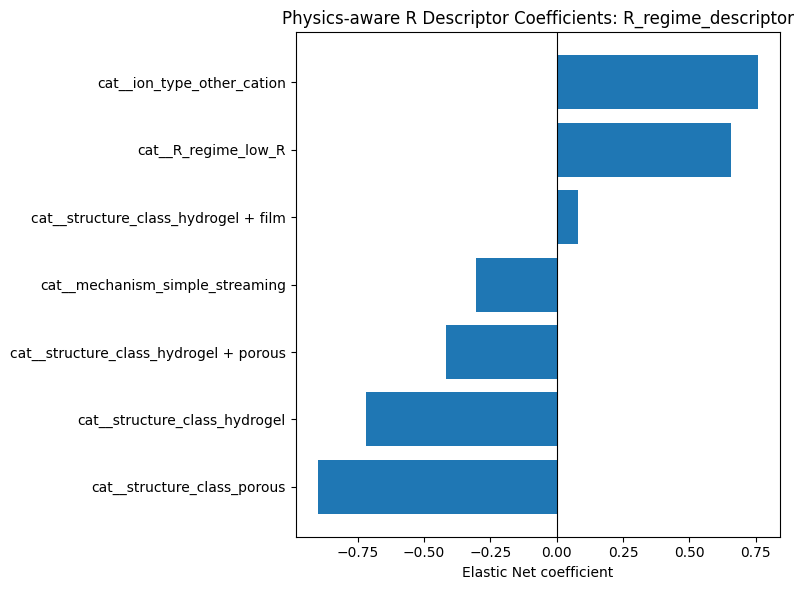

In [20]:
# Plot coefficient ranking
plot_df = nonzero_coef_df.head(20).sort_values("coefficient")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)

plt.xlabel("Elastic Net coefficient")
plt.title(f"Physics-aware R Descriptor Coefficients: {best_model_name}")

plt.tight_layout()
plt.show()

## Part D — Resistance regime analysis 

In [21]:
# Compare performance by R regime
regime_summary = (
    df_phys
    .dropna(subset=[TARGET, "R_regime"])
    .groupby("R_regime")[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

regime_summary

,R_regime,count,mean,median,std
0,high_R,103,-0.785167,-0.920815,1.300486
1,low_R,56,0.364812,0.451969,1.016194


In [22]:
regime_summary.to_csv(
    "../results/11_R_regime_performance_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

C:\Users\wenlu\AppData\Local\Temp\ipykernel_3692\1476989042.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["low_R", "high_R"])


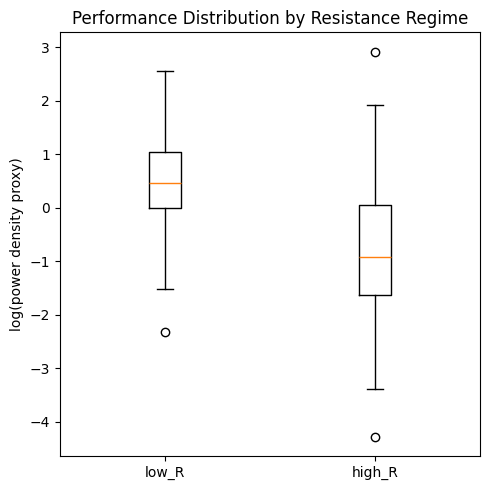

In [23]:
# Boxplot by R regime
plot_data = df_phys.dropna(subset=[TARGET, "R_regime"])

plt.figure(figsize=(5, 5))

groups = [
    plot_data.loc[plot_data["R_regime"] == "low_R", TARGET],
    plot_data.loc[plot_data["R_regime"] == "high_R", TARGET]
]

plt.boxplot(groups, labels=["low_R", "high_R"])

plt.ylabel("log(power density proxy)")
plt.title("Performance Distribution by Resistance Regime")

plt.tight_layout()
plt.show()

In [25]:
# Structure + R regime summary
if "structure_class" in df_phys.columns:
    structure_regime_summary = (
        df_phys
        .dropna(subset=[TARGET, "R_regime", "structure_class"])
        .groupby(["structure_class", "R_regime"])[TARGET]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    
    structure_regime_summary.to_csv(
        "../results/11_structure_R_regime_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )
    
    structure_regime_summary

The physics-aware resistance analysis shows that a regime-based resistance descriptor outperforms the continuous logR descriptor, suggesting that hydrovoltaic devices are better described by resistance-controlled performance regimes rather than by a purely continuous resistance scaling. Low-resistance devices exhibit substantially higher power-density proxy values than high-resistance devices across structural classes. This supports the interpretation of internal resistance as a transport-governing descriptor and indicates that reducing resistance below a critical regime is a primary design objective.